
# Projeto EBAC + Semantix
# Análise, Segmentação e Previsão de Vendas em um E-commerce Brasileiro

**Objetivo:** identificar padrões de compra, segmentar clientes e prever o valor das vendas utilizando técnicas de Estatística e Machine Learning.


In [4]:

!pip -q install xgboost plotly seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
from xgboost import XGBRegressor

plt.rcParams['figure.figsize'] = (10,5)


## 1. Carregamento dos Dados

In [3]:
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')

## 2. Preparação da Base

In [5]:

base = orders.merge(payments,on='order_id',how='left')
base = base.merge(customers,on='customer_id',how='left')

base['order_purchase_timestamp'] = pd.to_datetime(base['order_purchase_timestamp'])
base['mes'] = base['order_purchase_timestamp'].dt.to_period('M')

base.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,mes
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,credit_card,1.0,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3.0,voucher,1.0,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2.0,voucher,1.0,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,boleto,1.0,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,credit_card,3.0,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08


## 3. Estatística Descritiva

In [6]:

base['payment_value'].describe()


,payment_value
count,103886.000000
mean,154.100380
std,217.494064
min,0.000000
25%,56.790000
50%,100.000000
75%,171.837500
max,13664.080000


## 4. Evolução das Vendas

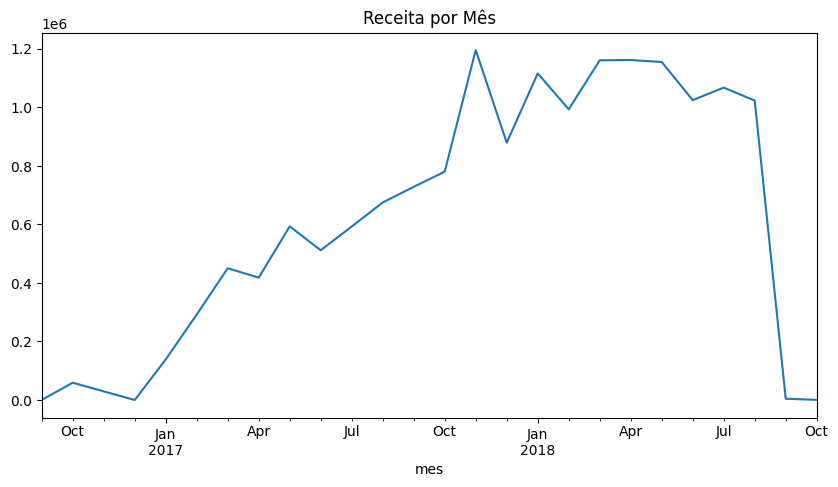

In [7]:

vendas_mes = base.groupby('mes')['payment_value'].sum()

vendas_mes.plot(kind='line')
plt.title('Receita por Mês')
plt.show()


## 5. Distribuição do Valor das Compras

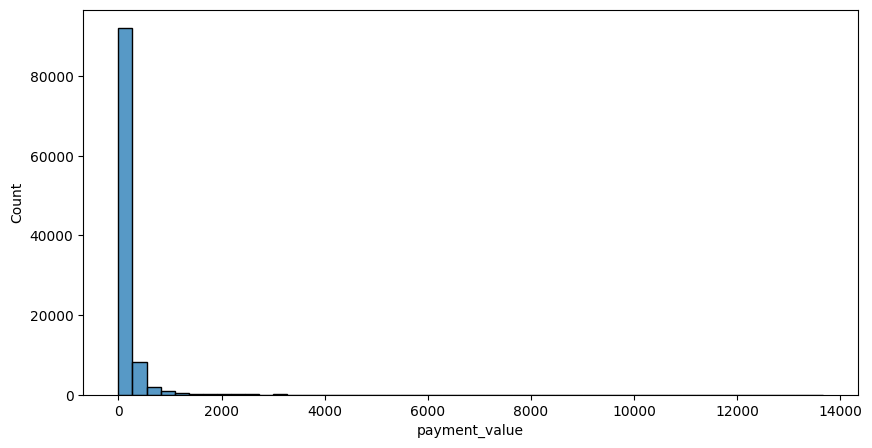

In [8]:

sns.histplot(base['payment_value'], bins=50)
plt.show()


## 6. Inferência Estatística

In [9]:

media = base['payment_value'].mean()

intervalo = stats.t.interval(
    confidence=0.95,
    df=len(base)-1,
    loc=media,
    scale=stats.sem(base['payment_value'])
)

print('Média:', media)
print('IC 95%:', intervalo)


Média: 154.10038041699553
IC 95%: (np.float64(nan), np.float64(nan))


## 7. Segmentação de Clientes

In [13]:
rfm = base.groupby('customer_unique_id').agg({
    'payment_value':['sum','mean','count']
})

rfm.columns=['valor_total','ticket_medio','qtd_pedidos']
rfm = rfm.reset_index()

rfm = rfm.fillna(0)

scaler = StandardScaler()

X = scaler.fit_transform(
    rfm[['valor_total','ticket_medio','qtd_pedidos']]
)


### Método do Cotovelo

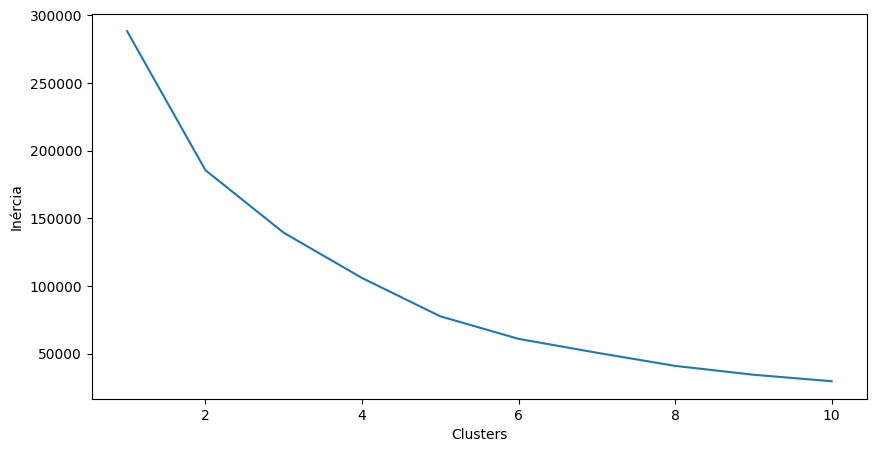

In [14]:

inercia=[]

for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inercia.append(km.inertia_)

plt.plot(range(1,11), inercia)
plt.xlabel('Clusters')
plt.ylabel('Inércia')
plt.show()


### PCA + KMeans

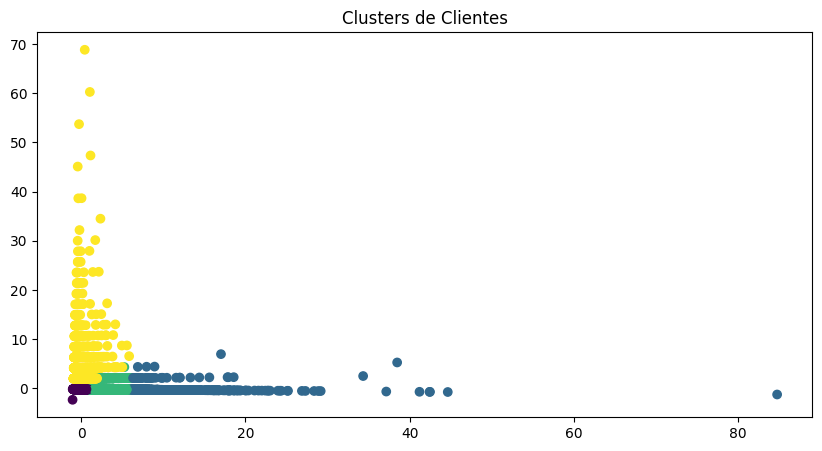

,customer_unique_id,valor_total,ticket_medio,qtd_pedidos,cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,141.90,1,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,27.19,1,0
2,0000f46a3911fa3c0805444483337064,86.22,86.22,1,0
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,43.62,1,0
4,0004aac84e0df4da2b147fca70cf8255,196.89,196.89,1,0


In [15]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title('Clusters de Clientes')
plt.show()

rfm['cluster'] = clusters
rfm.head()


## 8. Machine Learning

In [16]:

X = rfm[['ticket_medio','qtd_pedidos','cluster']]
y = rfm['valor_total']

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

modelos = {
    'Linear': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

resultado=[]

for nome,modelo in modelos.items():
    modelo.fit(X_train,y_train)
    pred = modelo.predict(X_test)

    resultado.append([
        nome,
        mean_absolute_error(y_test,pred),
        np.sqrt(mean_squared_error(y_test,pred)),
        r2_score(y_test,pred)
    ])

resultado = pd.DataFrame(
    resultado,
    columns=['Modelo','MAE','RMSE','R2']
)

resultado.sort_values('R2',ascending=False)


,Modelo,MAE,RMSE,R2
0,Linear,8.626836,48.351674,0.961818
1,DecisionTree,0.610881,49.200968,0.960465
2,RandomForest,0.636099,50.610186,0.958168
3,XGBoost,4.092274,96.496669,0.847925


## 9. Cross Validation

In [17]:

modelo = RandomForestRegressor(random_state=42)

scores = cross_val_score(
    modelo,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)
print('R2 Médio:', scores.mean())


[0.96052071 0.96629638 0.99895217 0.9938563  0.98607884]
R2 Médio: 0.9811408817605226



# Conclusão

- Foram identificados padrões de comportamento dos clientes.
- A segmentação permitiu separar grupos de consumidores.
- Os modelos preditivos mostraram potencial para previsão de valor de compra.
- Técnicas de Ciência de Dados podem apoiar decisões estratégicas em e-commerce.
